In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ramya18145/crater-model/crater_detector_best.pt


In [10]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # use only first T4

In [11]:
import os, math, random, glob, requests, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import torch

BASE = '/kaggle/working/'
for d in ['tiles', 'labels']:
    os.makedirs(f'{BASE}{d}', exist_ok=True)

print("Setup done ✓")

Setup done ✓


In [12]:
CATALOGUE_PATH = '/kaggle/working/labels/LROCCraters.csv'

CATALOGUE_URL = 'https://raw.githubusercontent.com/silburt/DeepMoon/master/catalogues/LROCCraters.csv'
r = requests.get(CATALOGUE_URL)

with open(CATALOGUE_PATH, 'wb') as f:
    f.write(r.content)

df_raw = pd.read_csv(CATALOGUE_PATH)
df_raw = df_raw.rename(columns={'Lat': 'lat', 'Long': 'lon', 'Diameter (km)': 'diameter_km'})
df = df_raw[df_raw['tag'] == 'standard'][['diameter_km', 'lon', 'lat']].reset_index(drop=True)

print(f"Craters in catalogue: {len(df)}")

Craters in catalogue: 14914


In [13]:
ZOOM      = 7
TILE_SIZE = 256
BASE_URL  = 'https://trek.nasa.gov/tiles/Moon/EQ/LRO_WAC_Mosaic_Global_303ppd_v02/1.0.0/default/default028mm'

def latlon_to_tile(lat, lon, zoom):
    n = 2 ** zoom
    x = int((lon + 180.0) / 360.0 * n)
    y = int((90.0 - lat) / 180.0 * n)
    return max(0, min(x, n-1)), max(0, min(y, n-1))

def latlon_to_pixel(lat, lon, zoom, tile_size=TILE_SIZE):
    n = 2 ** zoom
    x_tile, y_tile = latlon_to_tile(lat, lon, zoom)
    px = int(((lon + 180.0) / 360.0 * n - x_tile) * tile_size)
    py = int(((90.0 - lat) / 180.0 * n - y_tile) * tile_size)
    return x_tile, y_tile, px, py

# Find which tiles we need
needed_tiles = set()
for _, row in df.iterrows():
    x, y = latlon_to_tile(row['lat'], row['lon'], ZOOM)
    needed_tiles.add((x, y))

needed_tiles = {(x,y) for x,y in needed_tiles
                if not os.path.exists(f'{BASE}tiles/{ZOOM}_{x}_{y}.jpg')}
print(f'Tiles to download: {len(needed_tiles)}')

def download_tile(x, y):
    path = f'{BASE}tiles/{ZOOM}_{x}_{y}.jpg'
    url  = f'{BASE_URL}/{ZOOM}/{y}/{x}.jpg'
    try:
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            with open(path, 'wb') as f:
                f.write(r.content)
            return 'ok'
        return f'fail:{r.status_code}'
    except Exception as e:
        return f'error:{e}'

done, failed = 0, 0
with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {executor.submit(download_tile, x, y): (x,y) for x,y in needed_tiles}
    for future in tqdm(as_completed(futures), total=len(futures), desc='Downloading'):
        status = future.result()
        if status == 'ok': done += 1
        else: failed += 1

print(f'Done: {done} | Failed: {failed}')
print(f'Total tiles on disk: {len(os.listdir(BASE+"tiles"))}')

Tiles to download: 4161


Downloading: 100%|██████████| 4161/4161 [02:03<00:00, 33.60it/s]

Done: 4161 | Failed: 0
Total tiles on disk: 6796


In [14]:
def tile_to_latlon_bounds(x, y, zoom):
    n = 2 ** zoom
    lon_min = x / n * 360.0 - 180.0
    lon_max = (x + 1) / n * 360.0 - 180.0
    lat_max = 90.0 - y / n * 180.0
    lat_min = 90.0 - (y + 1) / n * 180.0
    return lat_max, lat_min, lon_min, lon_max

def pixel_to_latlon(px, py, x_tile, y_tile, zoom, tile_size=TILE_SIZE):
    n = 2 ** zoom
    lon = (x_tile + px / tile_size) / n * 360.0 - 180.0
    lat = 90.0 - (y_tile + py / tile_size) / n * 180.0
    return lat, lon

def haversine_km(lat1, lon1, lat2, lon2):
    R = 1737.4  # Moon radius km
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return R * 2 * math.asin(math.sqrt(a))

print("Geo helpers ready ✓")

Geo helpers ready ✓


In [16]:
import torch
print(torch.cuda.get_device_capability())  # Should print (6, 0)
print(torch.cuda.is_available())           # Should print True

(7, 5)
True


In [17]:
!pip install ultralytics -q

from ultralytics import YOLO

# ── Load your trained model from the dataset you attached ────────────
# Make sure you have attached your model weights as a Kaggle dataset
MODEL_PATH  = '/kaggle/input/datasets/ramya18145/crater-model/crater_detector_best.pt'  # update path if needed
OUTPUT_PATH = '/kaggle/working/craters.geojson'
CONF_THRESH = 0.25
BODY        = 'Moon'

model = YOLO(MODEL_PATH)

tile_files = [f for f in os.listdir(f'{BASE}tiles') if f.endswith('.jpg')]
print(f"Running on {len(tile_files)} tiles...")

features = []

for tile_file in tqdm(tile_files, desc="Detecting"):
    parts = tile_file.replace('.jpg', '').split('_')
    z, x_tile, y_tile = int(parts[0]), int(parts[1]), int(parts[2])

    img_path = f"{BASE}tiles/{tile_file}"
    results = model(img_path, conf=CONF_THRESH, verbose=False, imgsz=256)

    for box in results[0].boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf = float(box.conf[0].cpu().numpy())
        cx_px = (x1 + x2) / 2
        cy_px = (y1 + y2) / 2
        lat, lon = pixel_to_latlon(cx_px, cy_px, x_tile, y_tile, z)
        lat_left,  lon_left  = pixel_to_latlon(x1, cy_px, x_tile, y_tile, z)
        lat_right, lon_right = pixel_to_latlon(x2, cy_px, x_tile, y_tile, z)
        diameter_km = haversine_km(lat_left, lon_left, lat_right, lon_right)

        features.append({
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [float(lon), float(lat)]},
            "properties": {
                "confidence": round(float(conf), 3),
                "diameter_km": round(float(diameter_km), 2),
                "body": BODY,
                "tile": tile_file,
                "lat": round(float(lat), 5),
                "lon": round(float(lon), 5)
            }
        })

geojson = {"type": "FeatureCollection", "features": features}
with open(OUTPUT_PATH, 'w') as f:
    json.dump(geojson, f, indent=2)

print(f"\n✓ {len(features)} craters detected")
print(f"✓ Saved to {OUTPUT_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 4.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 11.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 31.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 102.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 20.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

Detecting: 100%|██████████| 6796/6796 [00:54<00:00, 125.37it/s]



✓ 10727 craters detected
✓ Saved to /kaggle/working/craters.geojson


In [18]:
!pip install folium -q
import folium

with open(OUTPUT_PATH) as f:
    gj = json.load(f)

lats = [f['properties']['lat'] for f in gj['features']]
lons = [f['properties']['lon'] for f in gj['features']]
center = [sum(lats)/len(lats), sum(lons)/len(lons)]

m = folium.Map(
    location=center,
    zoom_start=3,
    tiles='https://trek.nasa.gov/tiles/Moon/EQ/LRO_WAC_Mosaic_Global_303ppd_v02/1.0.0/default/default028mm/{z}/{y}/{x}.jpg',
    attr='NASA LRO WAC Mosaic',
    min_zoom=0, max_zoom=9
)

for feat in gj['features']:
    p = feat['properties']
    folium.CircleMarker(
        location=[p['lat'], p['lon']],
        radius=max(5, min(p['diameter_km'] * 0.8, 40)),
        color='#ff4500', fill=True, fill_color='#ff4500', fill_opacity=0.4,
        popup=folium.Popup(
            f"<b>Crater</b><br>Diameter: {p['diameter_km']} km<br>"
            f"Confidence: {p['confidence']}<br>"
            f"Lat: {p['lat']}, Lon: {p['lon']}<br>Tile: {p['tile']}",
            max_width=200)
    ).add_to(m)

m.save('/kaggle/working/crater_map.html')
print(f"Map saved ✓ | Craters: {len(gj['features'])}")


Map saved ✓ | Craters: 10727


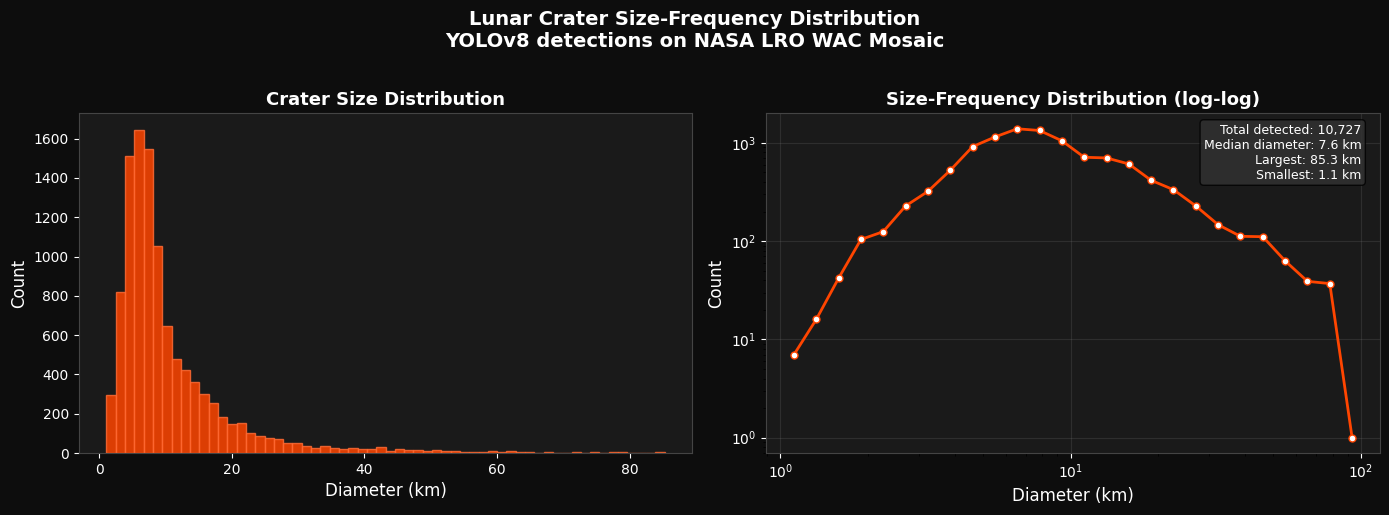

SFD plot saved ✓


In [19]:
diameters = [f['properties']['diameter_km'] for f in gj['features']]
diameters = [d for d in diameters if 0.5 < d < 500]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d0d0d')
for ax in axes: ax.set_facecolor('#1a1a1a')

axes[0].hist(diameters, bins=60, color='#ff4500', edgecolor='#ff6a33', alpha=0.85)
axes[0].set_xlabel('Diameter (km)', color='white', fontsize=12)
axes[0].set_ylabel('Count', color='white', fontsize=12)
axes[0].set_title('Crater Size Distribution', color='white', fontsize=13, fontweight='bold')
axes[0].tick_params(colors='white')
for spine in axes[0].spines.values(): spine.set_edgecolor('#444')

bins = np.logspace(np.log10(0.5), np.log10(500), 40)
counts, edges = np.histogram(diameters, bins=bins)
bin_centers = (edges[:-1] + edges[1:]) / 2
mask = counts > 0
axes[1].loglog(bin_centers[mask], counts[mask], 'o-', color='#ff4500',
               linewidth=2, markersize=5, markerfacecolor='white')
axes[1].set_xlabel('Diameter (km)', color='white', fontsize=12)
axes[1].set_ylabel('Count', color='white', fontsize=12)
axes[1].set_title('Size-Frequency Distribution (log-log)', color='white', fontsize=13, fontweight='bold')
axes[1].tick_params(colors='white')
axes[1].grid(True, alpha=0.2, color='gray')
for spine in axes[1].spines.values(): spine.set_edgecolor('#444')

stats_text = (f"Total detected: {len(diameters):,}\n"
              f"Median diameter: {np.median(diameters):.1f} km\n"
              f"Largest: {max(diameters):.1f} km\n"
              f"Smallest: {min(diameters):.1f} km")
axes[1].text(0.97, 0.97, stats_text, transform=axes[1].transAxes,
             fontsize=9, color='white', va='top', ha='right',
             bbox=dict(boxstyle='round', facecolor='#333', alpha=0.8))

plt.suptitle('Lunar Crater Size-Frequency Distribution\nYOLOv8 detections on NASA LRO WAC Mosaic',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/sfd_plot.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("SFD plot saved ✓")

In [24]:
import shutil
import os
import zipfile
from IPython.display import FileLink

folder = '/kaggle/working/crater_outputs'
zip_path = '/kaggle/working/crater_outputs.zip'

# Get total size for progress tracking
total_files = sum(len(files) for _, _, files in os.walk(folder))
zipped = 0

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for dirpath, dirnames, filenames in os.walk(folder):
        for filename in filenames:
            filepath = os.path.join(dirpath, filename)
            arcname = os.path.relpath(filepath, folder)
            zf.write(filepath, arcname)
            zipped += 1
            pct = (zipped / total_files) * 100
            print(f"\rZipping... {zipped}/{total_files} files ({pct:.1f}%)", end='', flush=True)

print(f"\n✅ Done! Archive size: {os.path.getsize(zip_path) / 1e6:.1f} MB")
FileLink('crater_outputs.zip')


✅ Done! Archive size: 0.0 MB


/kaggle/working/crater_outputs.zip

In [25]:
import os

# Search for any csv/geojson/png files in /kaggle/working
for dirpath, dirnames, filenames in os.walk('/kaggle/working'):
    for f in filenames:
        full = os.path.join(dirpath, f)
        size = os.path.getsize(full)
        if size > 0:
            print(f"{full}  ({size/1e3:.1f} KB)")

/kaggle/working/crater_map.html  (12118.5 KB)
/kaggle/working/crater_outputs.zip  (0.0 KB)
/kaggle/working/craters.geojson  (4065.9 KB)
/kaggle/working/sfd_plot.png  (117.5 KB)
/kaggle/working/tiles/7_21_40.jpg  (42.1 KB)
/kaggle/working/tiles/7_6_100.jpg  (41.6 KB)
/kaggle/working/tiles/7_104_77.jpg  (29.7 KB)
/kaggle/working/tiles/7_48_91.jpg  (38.5 KB)
/kaggle/working/tiles/7_24_25.jpg  (44.4 KB)
/kaggle/working/tiles/7_19_87.jpg  (37.5 KB)
/kaggle/working/tiles/7_116_52.jpg  (33.5 KB)
/kaggle/working/tiles/7_98_61.jpg  (27.4 KB)
/kaggle/working/tiles/7_14_42.jpg  (44.7 KB)
/kaggle/working/tiles/7_97_72.jpg  (28.8 KB)
/kaggle/working/tiles/7_1_60.jpg  (43.3 KB)
/kaggle/working/tiles/7_123_34.jpg  (32.3 KB)
/kaggle/working/tiles/7_47_60.jpg  (41.5 KB)
/kaggle/working/tiles/7_26_28.jpg  (41.8 KB)
/kaggle/working/tiles/7_94_32.jpg  (34.6 KB)
/kaggle/working/tiles/7_92_40.jpg  (28.0 KB)
/kaggle/working/tiles/7_87_77.jpg  (33.7 KB)
/kaggle/working/tiles/7_87_59.jpg  (25.6 KB)
/kaggle/wor

In [26]:
import os
import zipfile
from IPython.display import FileLink

# Files to include
files_to_zip = [
    '/kaggle/working/crater_map.html',
    '/kaggle/working/craters.geojson',
    '/kaggle/working/sfd_plot.png',
    '/kaggle/working/labels/LROCCraters.csv',
]

zip_path = '/kaggle/working/crater_outputs.zip'
total = len(files_to_zip)

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for i, filepath in enumerate(files_to_zip, 1):
        if os.path.exists(filepath):
            arcname = os.path.basename(filepath)
            zf.write(filepath, arcname)
            pct = (i / total) * 100
            print(f"\rZipping... {i}/{total} files ({pct:.1f}%)", end='', flush=True)
        else:
            print(f"\nSkipping missing file: {filepath}")

print(f"\n✅ Done! Archive size: {os.path.getsize(zip_path) / 1e6:.1f} MB")
FileLink('crater_outputs.zip')

Zipping... 4/4 files (100.0%)
✅ Done! Archive size: 2.4 MB


/kaggle/working/crater_outputs.zip